# QuickCart: Exploratory Analysis

This notebook explores platform performance, delivery behavior, customer ratings, refund patterns, product categories, and feedback categories using the cleaned QuickCart dataset.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Cleaned Data

In [2]:
df = pd.read_csv("quickcart_cleaned_orders.csv")
df.head()

,order_id,customer_id,platform,order_time_raw,delivery_time_minutes,product_category,order_value_inr,customer_feedback_raw,service_rating,delivery_delay,refund_requested,feedback_category,delay_flag,refund_flag,rating_group,delivery_performance_group,order_value_segment
0,ORD000001,CUST2824,JioMart,19:29.5,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No,Positive Experience,0,0,High Rating,Standard Delivery,Medium Value Order
1,ORD000002,CUST1409,Blinkit,54:29.5,16,Dairy,279,Quick and reliable!,5,No,No,Positive Experience,0,0,High Rating,Fast Delivery,Low Value Order
2,ORD000003,CUST5506,JioMart,21:29.5,25,Beverages,599,Items missing from order.,2,No,Yes,Order Issue,0,1,Low Rating,Standard Delivery,Medium Value Order
3,ORD000004,CUST5012,JioMart,19:29.5,42,Beverages,946,Items missing from order.,2,Yes,Yes,Order Issue,1,1,Low Rating,Slow Delivery,High Value Order
4,ORD000005,CUST4657,Blinkit,49:29.5,30,Beverages,334,"Fast delivery, great service!",5,No,No,Positive Experience,0,0,High Rating,Standard Delivery,Low Value Order


**Observation:** The cleaned QuickCart dataset has been loaded successfully with standardized columns and business-ready features for analysis.

## EDA Overview

In [3]:
eda_overview = pd.DataFrame({
    "metric": [
        "Total Orders",
        "Total Columns",
        "Unique Customers",
        "Platforms",
        "Product Categories",
        "Average Delivery Time",
        "Average Order Value",
        "Average Service Rating",
        "Delivery Delay Rate",
        "Refund Request Rate"
    ],
    "value": [
        df.shape[0],
        df.shape[1],
        df["customer_id"].nunique(),
        df["platform"].nunique(),
        df["product_category"].nunique(),
        round(df["delivery_time_minutes"].mean(), 2),
        round(df["order_value_inr"].mean(), 2),
        round(df["service_rating"].mean(), 2),
        str(round(df["delay_flag"].mean() * 100, 2)) + "%",
        str(round(df["refund_flag"].mean() * 100, 2)) + "%"
    ]
})

eda_overview

,metric,value
0,Total Orders,100000
1,Total Columns,17
2,Unique Customers,9000
3,Platforms,3
4,Product Categories,6
5,Average Delivery Time,29.54
6,Average Order Value,590.99
7,Average Service Rating,3.24
8,Delivery Delay Rate,13.67%
9,Refund Request Rate,45.82%


**Observation:** The cleaned dataset contains 100,000 orders across 3 platforms and 6 product categories. The average delivery time is 29.54 minutes, while the refund request rate is 45.82%, making refund behavior a key area for deeper analysis.

## Platform Performance Analysis

In [4]:
platform_performance = (
    df.groupby("platform")
    .agg(
        total_orders=("order_id", "count"),
        unique_customers=("customer_id", "nunique"),
        avg_delivery_time=("delivery_time_minutes", "mean"),
        avg_order_value=("order_value_inr", "mean"),
        avg_service_rating=("service_rating", "mean"),
        delay_rate=("delay_flag", "mean"),
        refund_rate=("refund_flag", "mean")
    )
    .reset_index()
)

platform_performance["order_share"] = (
    platform_performance["total_orders"] / platform_performance["total_orders"].sum() * 100
)

platform_performance["delay_rate"] = platform_performance["delay_rate"] * 100
platform_performance["refund_rate"] = platform_performance["refund_rate"] * 100

platform_performance = platform_performance.round({
    "order_share": 2,
    "avg_delivery_time": 2,
    "avg_order_value": 2,
    "avg_service_rating": 2,
    "delay_rate": 2,
    "refund_rate": 2
})

platform_performance

,platform,total_orders,unique_customers,avg_delivery_time,avg_order_value,avg_service_rating,delay_rate,refund_rate,order_share
0,Blinkit,33424,8767,29.47,589.55,3.23,13.38,45.93,33.42
1,JioMart,33127,8764,29.63,590.53,3.25,13.83,45.82,33.13
2,Swiggy Instamart,33449,8795,29.50,592.90,3.24,13.81,45.71,33.45


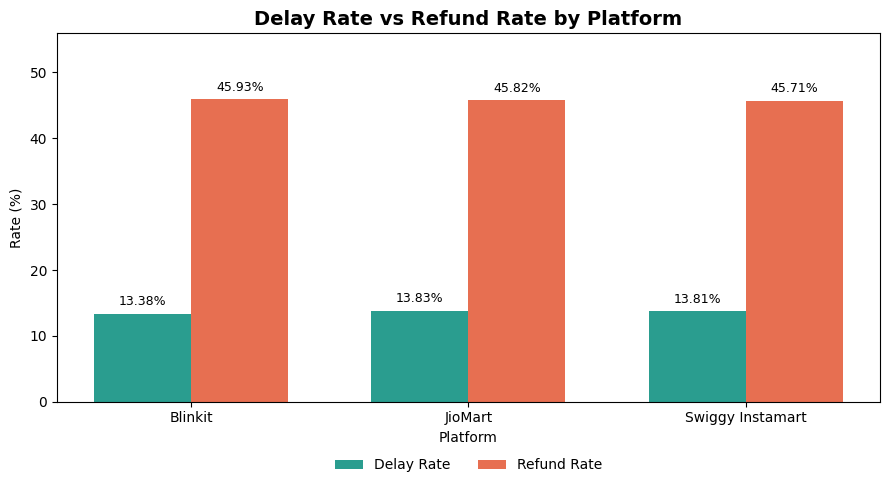

In [5]:
platform_risk_chart = platform_performance.copy()

x = range(len(platform_risk_chart["platform"]))
width = 0.35

plt.figure(figsize=(9, 5))

delay_bars = plt.bar(
    [i - width/2 for i in x],
    platform_risk_chart["delay_rate"],
    width,
    label="Delay Rate",
    color="#2A9D8F"
)

refund_bars = plt.bar(
    [i + width/2 for i in x],
    platform_risk_chart["refund_rate"],
    width,
    label="Refund Rate",
    color="#E76F51"
)

plt.title("Delay Rate vs Refund Rate by Platform", fontsize=14, fontweight="bold")
plt.xlabel("Platform")
plt.ylabel("Rate (%)")
plt.xticks(x, platform_risk_chart["platform"])
plt.ylim(0, platform_risk_chart["refund_rate"].max() + 10)

for bars in [delay_bars, refund_bars]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.8,
            f"{height:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()

**Observation:** Platform-level performance is broadly balanced across Blinkit, JioMart, and Swiggy Instamart. Order share, delivery time, order value, service rating, delay rate, and refund rate are very similar across all three platforms.

No platform shows a strong standalone performance gap at this stage. Refund rates remain high across all platforms at around 46%, while delay rates remain much lower at around 13–14%.

This suggests that refund behavior should be explored further using customer rating, feedback category, and issue-based patterns.

## Delivery Performance Analysis

In [6]:
delivery_performance_summary = (
    df.groupby("delivery_performance_group")
    .agg(
        total_orders=("order_id", "count"),
        avg_delivery_time=("delivery_time_minutes", "mean"),
        avg_service_rating=("service_rating", "mean"),
        delay_rate=("delay_flag", "mean"),
        refund_rate=("refund_flag", "mean")
    )
    .reset_index()
)

delivery_performance_summary["order_share"] = (
    delivery_performance_summary["total_orders"] / len(df) * 100
)

delivery_performance_summary["delay_rate"] = delivery_performance_summary["delay_rate"] * 100
delivery_performance_summary["refund_rate"] = delivery_performance_summary["refund_rate"] * 100

delivery_performance_summary = delivery_performance_summary.round({
    "avg_delivery_time": 2,
    "avg_service_rating": 2,
    "delay_rate": 2,
    "refund_rate": 2,
    "order_share": 2
})

delivery_performance_summary

,delivery_performance_group,total_orders,avg_delivery_time,avg_service_rating,delay_rate,refund_rate,order_share
0,Fast Delivery,27454,17.42,3.24,0.00,45.67,27.45
1,Slow Delivery,24263,42.43,3.24,56.35,45.84,24.26
2,Standard Delivery,48283,29.95,3.24,0.00,45.89,48.28


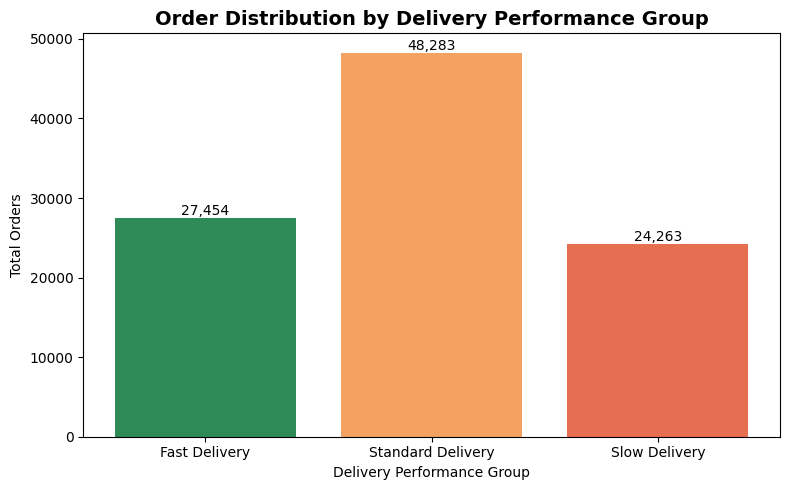

In [7]:
delivery_order = ["Fast Delivery", "Standard Delivery", "Slow Delivery"]

delivery_chart_data = (
    delivery_performance_summary
    .set_index("delivery_performance_group")
    .loc[delivery_order]
    .reset_index()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    delivery_chart_data["delivery_performance_group"],
    delivery_chart_data["total_orders"],
    color=["#2E8B57", "#F4A261", "#E76F51"]
)

plt.title("Order Distribution by Delivery Performance Group", fontsize=14, fontweight="bold")
plt.xlabel("Delivery Performance Group")
plt.ylabel("Total Orders")
plt.xticks(rotation=0)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

**Observation:** Most orders fall under the Standard Delivery group, representing 48.28% of total orders. Fast Delivery accounts for 27.45%, while Slow Delivery accounts for 24.26%.

Slow Delivery has the highest delay rate at 56.35%, while Fast and Standard Delivery groups show no delay cases. However, average service ratings remain almost identical across all delivery groups at 3.24, suggesting that delivery performance does not show a strong difference in customer rating at this stage.

Refund rates are high across all delivery groups, remaining around 46%. This suggests that refund behavior may not be driven by delivery speed alone and should be further analyzed using feedback category, rating group, product category, and order issue patterns.

## Customer Rating Analysis

In [8]:
rating_summary = (
    df.groupby("service_rating")
    .agg(
        total_orders=("order_id", "count"),
        avg_delivery_time=("delivery_time_minutes", "mean"),
        avg_order_value=("order_value_inr", "mean"),
        delay_rate=("delay_flag", "mean"),
        refund_rate=("refund_flag", "mean")
    )
    .reset_index()
    .sort_values("service_rating")
)

rating_summary["order_share"] = (
    rating_summary["total_orders"] / len(df) * 100
)

rating_summary["delay_rate"] = rating_summary["delay_rate"] * 100
rating_summary["refund_rate"] = rating_summary["refund_rate"] * 100

rating_summary = rating_summary.round({
    "avg_delivery_time": 2,
    "avg_order_value": 2,
    "delay_rate": 2,
    "refund_rate": 2,
    "order_share": 2
})

rating_summary

,service_rating,total_orders,avg_delivery_time,avg_order_value,delay_rate,refund_rate,order_share
0,1,15267,29.52,595.47,13.76,100.0,15.27
1,2,30552,29.56,590.56,13.74,100.0,30.55
2,3,7704,29.43,589.49,13.76,0.0,7.70
3,4,7789,29.62,586.69,13.85,0.0,7.79
4,5,38688,29.53,590.74,13.53,0.0,38.69


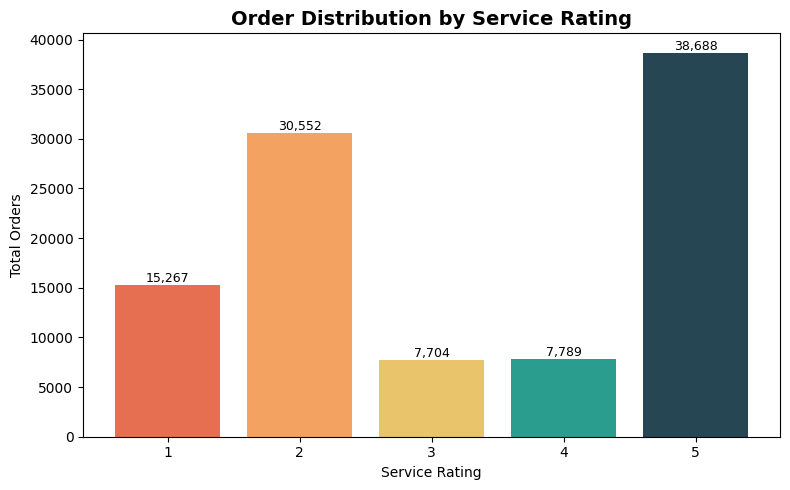

In [9]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    rating_summary["service_rating"].astype(str),
    rating_summary["total_orders"],
    color=["#E76F51", "#F4A261", "#E9C46A", "#2A9D8F", "#264653"]
)

plt.title("Order Distribution by Service Rating", fontsize=14, fontweight="bold")
plt.xlabel("Service Rating")
plt.ylabel("Total Orders")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Observation:** Customer ratings are highly polarized. 5-star ratings represent the largest share of orders at 38.69%, followed by 2-star ratings at 30.55% and 1-star ratings at 15.27%. Ratings 3 and 4 have much lower order shares.

Average delivery time, average order value, and delay rate remain broadly similar across rating levels.

The strongest pattern appears in refund behavior. Orders rated 1 or 2 have a 100% refund request rate, while orders rated 3, 4, and 5 have a 0% refund request rate. This makes low service rating a key customer experience risk signal.

## Refund Behavior Analysis

In [10]:
refund_summary = (
    df.groupby("refund_requested")
    .agg(
        total_orders=("order_id", "count"),
        avg_delivery_time=("delivery_time_minutes", "mean"),
        avg_order_value=("order_value_inr", "mean"),
        avg_service_rating=("service_rating", "mean"),
        delay_rate=("delay_flag", "mean")
    )
    .reset_index()
)

refund_summary["order_share"] = (
    refund_summary["total_orders"] / len(df) * 100
)

refund_summary["delay_rate"] = refund_summary["delay_rate"] * 100

refund_summary = refund_summary.round({
    "avg_delivery_time": 2,
    "avg_order_value": 2,
    "avg_service_rating": 2,
    "delay_rate": 2,
    "order_share": 2
})

refund_summary

,refund_requested,total_orders,avg_delivery_time,avg_order_value,avg_service_rating,delay_rate,order_share
0,No,54181,29.53,589.98,4.57,13.61,54.18
1,Yes,45819,29.54,592.20,1.67,13.75,45.82


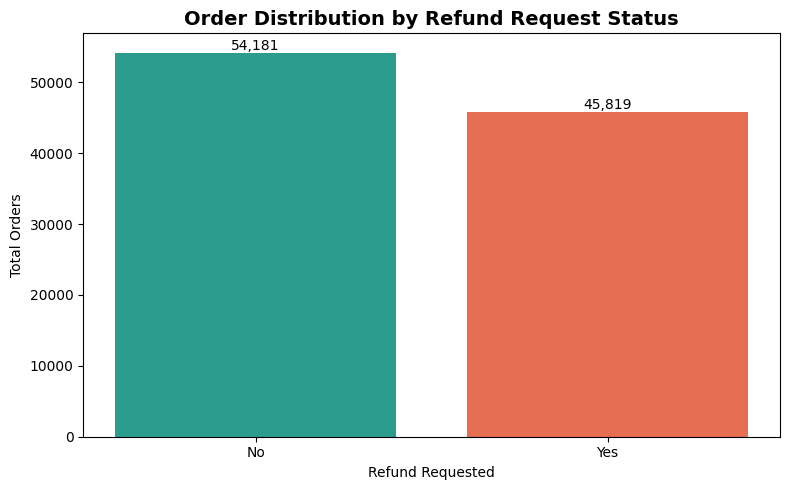

In [11]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    refund_summary["refund_requested"],
    refund_summary["total_orders"],
    color=["#2A9D8F", "#E76F51"]
)

plt.title("Order Distribution by Refund Request Status", fontsize=14, fontweight="bold")
plt.xlabel("Refund Requested")
plt.ylabel("Total Orders")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

**Observation:** Refund requests represent a major business concern, with 45.82% of total orders having a refund request.

Refund-requested orders have a much lower average service rating of 1.67, compared with 4.57 for orders without refund requests.

Average delivery time, average order value, and delay rate remain very similar across both groups. This suggests that refund behavior is more clearly connected with customer rating than with delivery speed or order value at this aggregate stage.

## Product Category Analysis

In [12]:
category_summary = (
    df.groupby("product_category")
    .agg(
        total_orders=("order_id", "count"),
        avg_delivery_time=("delivery_time_minutes", "mean"),
        avg_order_value=("order_value_inr", "mean"),
        avg_service_rating=("service_rating", "mean"),
        delay_rate=("delay_flag", "mean"),
        refund_rate=("refund_flag", "mean")
    )
    .reset_index()
)

category_summary["order_share"] = (
    category_summary["total_orders"] / len(df) * 100
)

category_summary["delay_rate"] = category_summary["delay_rate"] * 100
category_summary["refund_rate"] = category_summary["refund_rate"] * 100

category_summary = category_summary.round({
    "avg_delivery_time": 2,
    "avg_order_value": 2,
    "avg_service_rating": 2,
    "delay_rate": 2,
    "refund_rate": 2,
    "order_share": 2
})

category_summary.sort_values("refund_rate", ascending=False)

,product_category,total_orders,avg_delivery_time,avg_order_value,avg_service_rating,delay_rate,refund_rate,order_share
3,Grocery,16737,29.58,848.06,3.22,13.82,46.67,16.74
2,Fruits & Vegetables,16632,29.55,375.57,3.23,13.77,46.25,16.63
0,Beverages,16536,29.50,549.51,3.25,13.52,45.65,16.54
1,Dairy,16857,29.56,451.48,3.24,13.72,45.62,16.86
4,Personal Care,16533,29.57,1052.17,3.25,13.63,45.47,16.53
5,Snacks,16705,29.45,273.34,3.25,13.57,45.25,16.71


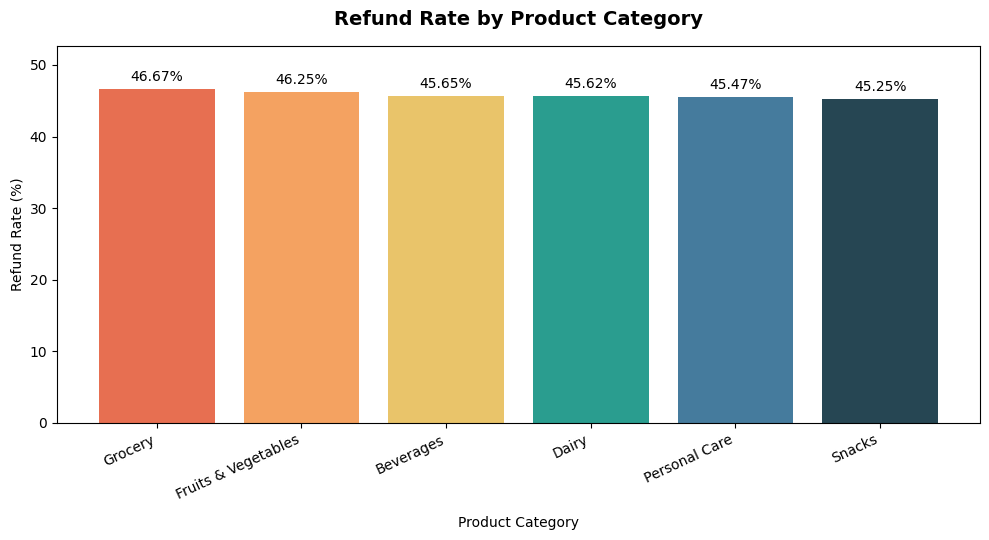

In [13]:
category_chart_data = category_summary.sort_values("refund_rate", ascending=False)

plt.figure(figsize=(10, 5.5))

bars = plt.bar(
    category_chart_data["product_category"],
    category_chart_data["refund_rate"],
    color=["#E76F51", "#F4A261", "#E9C46A", "#2A9D8F", "#457B9D", "#264653"]
)

plt.title("Refund Rate by Product Category", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Product Category", labelpad=10)
plt.ylabel("Refund Rate (%)")

plt.xticks(rotation=25, ha="right")

plt.ylim(0, category_chart_data["refund_rate"].max() + 6)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.7,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

**Observation:** Product category distribution is broadly balanced, with each category contributing around 16–17% of total orders.

Average delivery time, service rating, delay rate, and refund rate remain very similar across categories.

The main difference appears in average order value. Personal Care has the highest average order value at ₹1,052.17, followed by Grocery at ₹848.06, while Snacks has the lowest average order value at ₹273.34.

This suggests that product category is useful for spending analysis, but not a strong standalone driver of refunds or rating differences at this stage.

## Feedback Category Analysis

In [14]:
feedback_summary = (
    df.groupby("feedback_category")
    .agg(
        total_orders=("order_id", "count"),
        avg_delivery_time=("delivery_time_minutes", "mean"),
        avg_order_value=("order_value_inr", "mean"),
        avg_service_rating=("service_rating", "mean"),
        delay_rate=("delay_flag", "mean"),
        refund_rate=("refund_flag", "mean")
    )
    .reset_index()
)

feedback_summary["order_share"] = (
    feedback_summary["total_orders"] / len(df) * 100
)

feedback_summary["delay_rate"] = feedback_summary["delay_rate"] * 100
feedback_summary["refund_rate"] = feedback_summary["refund_rate"] * 100

feedback_summary = feedback_summary.round({
    "avg_delivery_time": 2,
    "avg_order_value": 2,
    "avg_service_rating": 2,
    "delay_rate": 2,
    "refund_rate": 2,
    "order_share": 2
})

feedback_summary.sort_values("refund_rate", ascending=False).reset_index(drop=True)

,feedback_category,total_orders,avg_delivery_time,avg_order_value,avg_service_rating,delay_rate,refund_rate,order_share
0,Delivery Issue,7592,29.57,584.36,2.00,13.75,100.0,7.59
1,Negative Experience,7529,29.56,594.28,1.00,13.67,100.0,7.53
2,Order Issue,15475,29.61,595.69,1.50,14.15,100.0,15.48
3,Service Issue,7643,29.53,594.69,2.00,13.50,100.0,7.64
4,Product Quality Issue,7580,29.40,588.34,2.00,13.23,100.0,7.58
5,Positive Experience,46477,29.55,590.06,4.83,13.59,0.0,46.48
6,Packaging Issue,7704,29.43,589.49,3.00,13.76,0.0,7.70


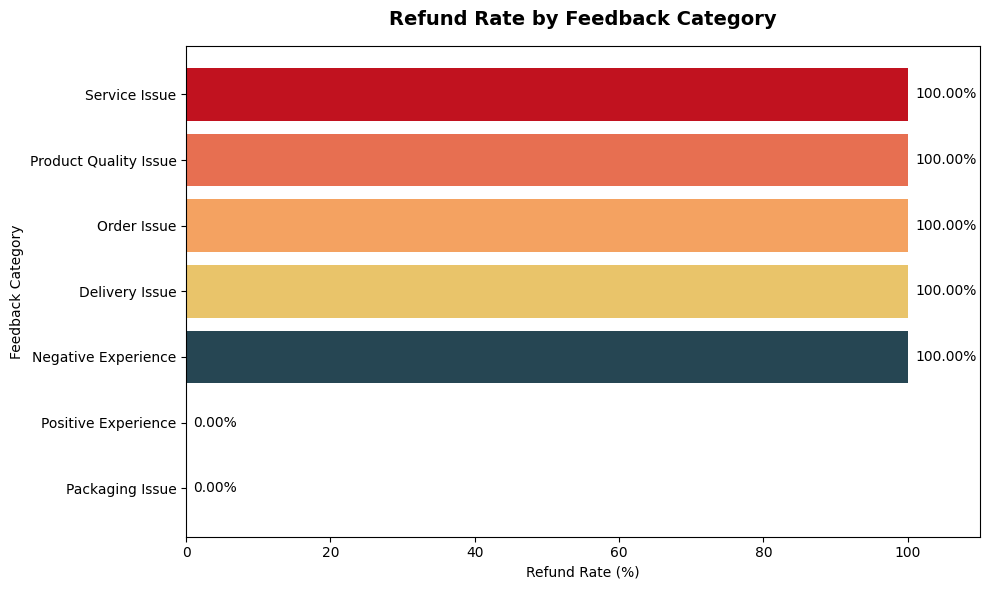

In [15]:
feedback_chart_data = feedback_summary.sort_values("refund_rate", ascending=True)

colors = [
    "#2A9D8F",
    "#457B9D",
    "#264653",
    "#E9C46A",
    "#F4A261",
    "#E76F51",
    "#C1121F"
]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    feedback_chart_data["feedback_category"],
    feedback_chart_data["refund_rate"],
    color=colors[:len(feedback_chart_data)]
)

plt.title("Refund Rate by Feedback Category", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Refund Rate (%)")
plt.ylabel("Feedback Category")

plt.xlim(0, feedback_chart_data["refund_rate"].max() + 10)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

**Observation:** Feedback category shows the clearest refund pattern so far. Positive Experience has the highest order share at 46.48% and the highest average rating at 4.83.

Issue-based categories such as Order Issue, Delivery Issue, Service Issue, Product Quality Issue, and Negative Experience show a 100% refund request rate. In contrast, Positive Experience and Packaging Issue show a 0% refund request rate.

This suggests that refund requests are mainly concentrated in issue-based feedback categories, making feedback category an important field for deeper customer experience and refund analysis.


## Refund Relationship Analysis

In [16]:
issue_feedback_categories = [
    "Order Issue",
    "Delivery Issue",
    "Service Issue",
    "Product Quality Issue",
    "Negative Experience"
]

relationship_summary = pd.DataFrame({
    "analysis_area": [
        "Delayed Orders",
        "Non-Delayed Orders",
        "Low Rating Orders",
        "Medium/High Rating Orders",
        "Issue-Based Feedback Orders",
        "Non-Issue Feedback Orders"
    ],
    "total_orders": [
        df[df["delivery_delay"] == "Yes"].shape[0],
        df[df["delivery_delay"] == "No"].shape[0],
        df[df["rating_group"] == "Low Rating"].shape[0],
        df[df["rating_group"] != "Low Rating"].shape[0],
        df[df["feedback_category"].isin(issue_feedback_categories)].shape[0],
        df[~df["feedback_category"].isin(issue_feedback_categories)].shape[0]
    ],
    "refund_rate": [
        df[df["delivery_delay"] == "Yes"]["refund_flag"].mean() * 100,
        df[df["delivery_delay"] == "No"]["refund_flag"].mean() * 100,
        df[df["rating_group"] == "Low Rating"]["refund_flag"].mean() * 100,
        df[df["rating_group"] != "Low Rating"]["refund_flag"].mean() * 100,
        df[df["feedback_category"].isin(issue_feedback_categories)]["refund_flag"].mean() * 100,
        df[~df["feedback_category"].isin(issue_feedback_categories)]["refund_flag"].mean() * 100
    ]
})

relationship_summary["refund_rate"] = relationship_summary["refund_rate"].round(2)

relationship_summary

,analysis_area,total_orders,refund_rate
0,Delayed Orders,13672,46.06
1,Non-Delayed Orders,86328,45.78
2,Low Rating Orders,45819,100.00
3,Medium/High Rating Orders,54181,0.00
4,Issue-Based Feedback Orders,45819,100.00
5,Non-Issue Feedback Orders,54181,0.00


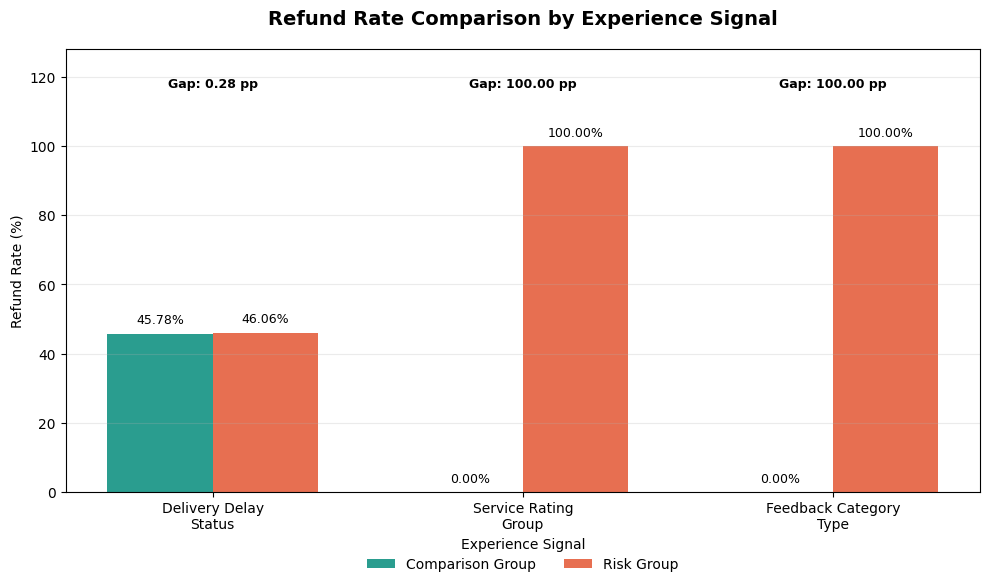

In [17]:
comparison_chart = pd.DataFrame({
    "signal": [
        "Delivery Delay\nStatus",
        "Service Rating\nGroup",
        "Feedback Category\nType"
    ],
    "comparison_rate": [
        relationship_summary.loc[relationship_summary["analysis_area"] == "Non-Delayed Orders", "refund_rate"].values[0],
        relationship_summary.loc[relationship_summary["analysis_area"] == "Medium/High Rating Orders", "refund_rate"].values[0],
        relationship_summary.loc[relationship_summary["analysis_area"] == "Non-Issue Feedback Orders", "refund_rate"].values[0]
    ],
    "risk_rate": [
        relationship_summary.loc[relationship_summary["analysis_area"] == "Delayed Orders", "refund_rate"].values[0],
        relationship_summary.loc[relationship_summary["analysis_area"] == "Low Rating Orders", "refund_rate"].values[0],
        relationship_summary.loc[relationship_summary["analysis_area"] == "Issue-Based Feedback Orders", "refund_rate"].values[0]
    ]
})

comparison_chart["refund_rate_gap"] = (
    comparison_chart["risk_rate"] - comparison_chart["comparison_rate"]
).abs().round(2)

x = np.arange(len(comparison_chart))
width = 0.34

plt.figure(figsize=(10, 6))

comparison_bars = plt.bar(
    x - width / 2,
    comparison_chart["comparison_rate"],
    width,
    label="Comparison Group",
    color="#2A9D8F"
)

risk_bars = plt.bar(
    x + width / 2,
    comparison_chart["risk_rate"],
    width,
    label="Risk Group",
    color="#E76F51"
)

plt.title(
    "Refund Rate Comparison by Experience Signal",
    fontsize=14,
    fontweight="bold",
    pad=18
)

plt.xlabel("Experience Signal")
plt.ylabel("Refund Rate (%)")
plt.xticks(x, comparison_chart["signal"])
plt.ylim(0, 128)

plt.grid(axis="y", alpha=0.25)

for bars in [comparison_bars, risk_bars]:
    for bar in bars:
        height = bar.get_height()
        label_y = height + 2 if height > 0 else 2

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            label_y,
            f"{height:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

for i, gap in enumerate(comparison_chart["refund_rate_gap"]):
    plt.text(
        x[i],
        118,
        f"Gap: {gap:.2f} pp",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()

**Observation:** Delivery delay shows almost no separation in refund behavior, with only a 0.28 percentage point gap between delayed and non-delayed orders.

Service rating and feedback category show the strongest refund separation. Low-rating orders and issue-based feedback orders have a 100% refund request rate, while medium/high-rating and non-issue feedback orders have a 0% refund request rate.

This suggests that refund requests are more clearly linked with customer rating and feedback category than with delivery delay status at this stage.

## Order Value Segment Analysis

In [18]:
order_value_summary = (
    df.groupby("order_value_segment")
    .agg(
        total_orders=("order_id", "count"),
        avg_order_value=("order_value_inr", "mean"),
        avg_delivery_time=("delivery_time_minutes", "mean"),
        avg_service_rating=("service_rating", "mean"),
        delay_rate=("delay_flag", "mean"),
        refund_rate=("refund_flag", "mean")
    )
    .reset_index()
)

order_value_summary["order_share"] = (
    order_value_summary["total_orders"] / len(df) * 100
)

order_value_summary["delay_rate"] = order_value_summary["delay_rate"] * 100
order_value_summary["refund_rate"] = order_value_summary["refund_rate"] * 100

order_value_summary = order_value_summary.round({
    "avg_order_value": 2,
    "avg_delivery_time": 2,
    "avg_service_rating": 2,
    "delay_rate": 2,
    "refund_rate": 2,
    "order_share": 2
})

segment_order = ["Low Value Order", "Medium Value Order", "High Value Order"]

order_value_summary = (
    order_value_summary
    .set_index("order_value_segment")
    .loc[segment_order]
    .reset_index()
)

order_value_summary

,order_value_segment,total_orders,avg_order_value,avg_delivery_time,avg_service_rating,delay_rate,refund_rate,order_share
0,Low Value Order,33416,213.00,29.46,3.25,13.57,45.63,33.42
1,Medium Value Order,33338,491.12,29.52,3.24,13.59,45.97,33.34
2,High Value Order,33246,1071.07,29.62,3.24,13.85,45.86,33.25


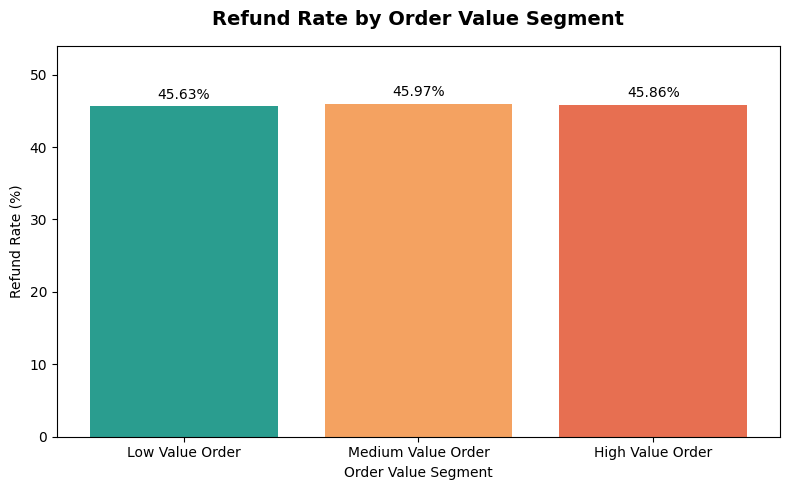

In [19]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    order_value_summary["order_value_segment"],
    order_value_summary["refund_rate"],
    color=["#2A9D8F", "#F4A261", "#E76F51"]
)

plt.title("Refund Rate by Order Value Segment", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Order Value Segment")
plt.ylabel("Refund Rate (%)")
plt.ylim(0, order_value_summary["refund_rate"].max() + 8)
plt.xticks(rotation=0)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.6,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

**Observation:** Order value segments are evenly distributed, with each segment contributing around one-third of total orders.

Average order value increases clearly from Low Value to High Value orders, confirming that the segmentation is working correctly. However, average delivery time, average service rating, delay rate, and refund rate remain very similar across all three segments.

This suggests that order value does not show a strong visible difference in refund behavior, delivery performance, or customer rating at this aggregate stage.

## Customer Frequency Analysis

In [30]:
# Create customer-level order frequency table
customer_order_frequency = (
    df.groupby("customer_id")
    .agg(total_orders_by_customer=("order_id", "count"))
    .reset_index()
)

# Create dataset-based frequency cutoffs
frequency_p25 = customer_order_frequency["total_orders_by_customer"].quantile(0.25)
frequency_p75 = customer_order_frequency["total_orders_by_customer"].quantile(0.75)

# Create customer frequency segment
def customer_frequency_segment(order_count):
    if order_count <= frequency_p25:
        return "Low Frequency Customer"
    elif order_count <= frequency_p75:
        return "Medium Frequency Customer"
    else:
        return "High Frequency Customer"

customer_order_frequency["customer_frequency_segment"] = (
    customer_order_frequency["total_orders_by_customer"].apply(customer_frequency_segment)
)

# Merge customer frequency segment back into order-level data
df_customer_frequency = df.merge(
    customer_order_frequency,
    on="customer_id",
    how="left"
)

# Customer-level summary
customer_segment_summary = (
    customer_order_frequency
    .groupby("customer_frequency_segment")
    .agg(
        unique_customers=("customer_id", "count"),
        total_orders=("total_orders_by_customer", "sum"),
        avg_orders_per_customer=("total_orders_by_customer", "mean"),
        min_orders_per_customer=("total_orders_by_customer", "min"),
        max_orders_per_customer=("total_orders_by_customer", "max")
    )
    .reset_index()
)

# Order-level behavior summary
customer_behavior_summary = (
    df_customer_frequency
    .groupby("customer_frequency_segment")
    .agg(
        avg_order_value=("order_value_inr", "mean"),
        avg_delivery_time=("delivery_time_minutes", "mean"),
        avg_service_rating=("service_rating", "mean"),
        delay_rate=("delay_flag", "mean"),
        refund_rate=("refund_flag", "mean")
    )
    .reset_index()
)

# Combine customer-level and order-level summaries
customer_frequency_summary = customer_segment_summary.merge(
    customer_behavior_summary,
    on="customer_frequency_segment",
    how="left"
)

customer_frequency_summary["customer_share"] = (
    customer_frequency_summary["unique_customers"] / df["customer_id"].nunique() * 100
)

customer_frequency_summary["order_share"] = (
    customer_frequency_summary["total_orders"] / len(df) * 100
)

customer_frequency_summary["delay_rate"] = customer_frequency_summary["delay_rate"] * 100
customer_frequency_summary["refund_rate"] = customer_frequency_summary["refund_rate"] * 100

customer_frequency_summary = customer_frequency_summary.round({
    "avg_orders_per_customer": 2,
    "avg_order_value": 2,
    "avg_delivery_time": 2,
    "avg_service_rating": 2,
    "delay_rate": 2,
    "refund_rate": 2,
    "customer_share": 2,
    "order_share": 2
})

segment_order = [
    "Low Frequency Customer",
    "Medium Frequency Customer",
    "High Frequency Customer"
]

customer_frequency_summary = (
    customer_frequency_summary
    .set_index("customer_frequency_segment")
    .loc[segment_order]
    .reset_index()
)

customer_frequency_summary

,customer_frequency_segment,unique_customers,total_orders,avg_orders_per_customer,min_orders_per_customer,max_orders_per_customer,avg_order_value,avg_delivery_time,avg_service_rating,delay_rate,refund_rate,customer_share,order_share
0,Low Frequency Customer,2941,22051,7.50,2,9,591.03,29.58,3.23,13.55,46.07,32.68,22.05
1,Medium Frequency Customer,3963,45132,11.39,10,13,590.95,29.54,3.24,13.72,45.92,44.03,45.13
2,High Frequency Customer,2096,32817,15.66,14,26,591.03,29.50,3.25,13.68,45.52,23.29,32.82


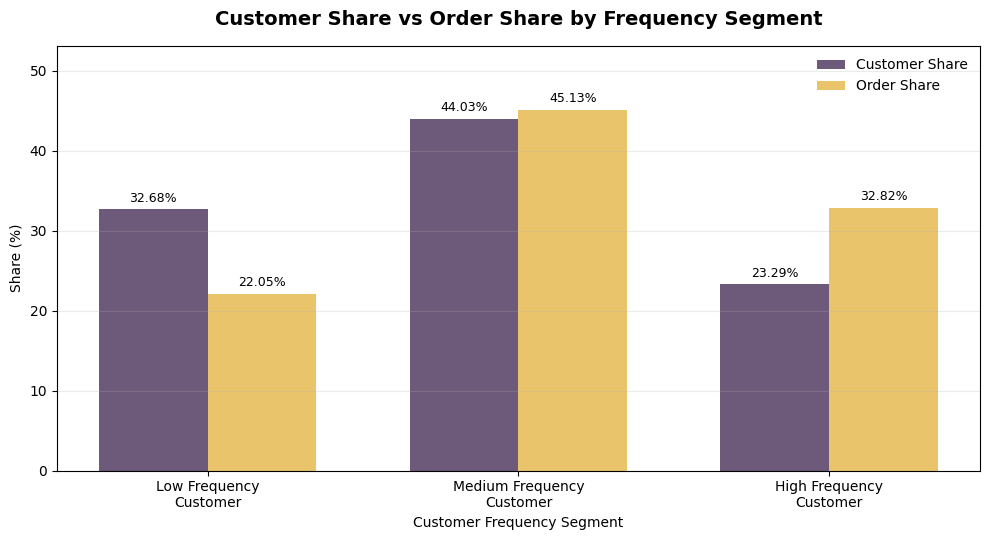

In [31]:
x = np.arange(len(customer_frequency_summary))
width = 0.35

plt.figure(figsize=(10, 5.5))

customer_bars = plt.bar(
    x - width / 2,
    customer_frequency_summary["customer_share"],
    width,
    label="Customer Share",
    color="#6D597A"
)

order_bars = plt.bar(
    x + width / 2,
    customer_frequency_summary["order_share"],
    width,
    label="Order Share",
    color="#E9C46A"
)

plt.title(
    "Customer Share vs Order Share by Frequency Segment",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Customer Frequency Segment")
plt.ylabel("Share (%)")

plt.xticks(
    x,
    ["Low Frequency\nCustomer", "Medium Frequency\nCustomer", "High Frequency\nCustomer"],
    rotation=0
)

plt.ylim(
    0,
    max(
        customer_frequency_summary["customer_share"].max(),
        customer_frequency_summary["order_share"].max()
    ) + 8
)

for bars in [customer_bars, order_bars]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.6,
            f"{height:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.legend(frameon=False)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

**Observation:** Customer frequency segments were created using dataset-based quartile cutoffs.

Medium Frequency customers represent the largest customer segment at 44.03% and contribute the highest order share at 45.13%. High Frequency customers represent only 23.29% of unique customers but generate 32.82% of total orders, indicating stronger repeat-order contribution.

Average order value, delivery time, service rating, delay rate, and refund rate remain broadly similar across all frequency segments. This suggests that customer frequency does not show a strong visible difference in refund behavior or delivery experience at this aggregate stage.

Overall, customer frequency is more useful for understanding repeat-order contribution than for explaining refund or rating differences in this analysis.


## Platform-Level Customer Repeat Analysis

In [27]:
platform_customer_frequency = (
    df.groupby(["platform", "customer_id"])
    .agg(
        orders_by_customer_platform=("order_id", "count")
    )
    .reset_index()
)

platform_customer_frequency["is_repeat_customer"] = (
    platform_customer_frequency["orders_by_customer_platform"] > 1
)

platform_customer_summary = (
    platform_customer_frequency
    .groupby("platform")
    .agg(
        unique_customers=("customer_id", "nunique"),
        repeat_customers=("is_repeat_customer", "sum"),
        total_orders=("orders_by_customer_platform", "sum"),
        avg_orders_per_customer=("orders_by_customer_platform", "mean"),
        max_orders_by_customer=("orders_by_customer_platform", "max")
    )
    .reset_index()
)

platform_customer_summary["repeat_customer_rate"] = (
    platform_customer_summary["repeat_customers"] / platform_customer_summary["unique_customers"] * 100
)

platform_behavior_summary = (
    df.groupby("platform")
    .agg(
        avg_order_value=("order_value_inr", "mean"),
        avg_delivery_time=("delivery_time_minutes", "mean"),
        avg_service_rating=("service_rating", "mean"),
        delay_rate=("delay_flag", "mean"),
        refund_rate=("refund_flag", "mean")
    )
    .reset_index()
)

platform_repeat_summary = platform_customer_summary.merge(
    platform_behavior_summary,
    on="platform",
    how="left"
)

platform_repeat_summary["order_share"] = (
    platform_repeat_summary["total_orders"] / len(df) * 100
)

platform_repeat_summary["delay_rate"] = platform_repeat_summary["delay_rate"] * 100
platform_repeat_summary["refund_rate"] = platform_repeat_summary["refund_rate"] * 100

platform_repeat_summary = platform_repeat_summary.round({
    "avg_orders_per_customer": 2,
    "repeat_customer_rate": 2,
    "avg_order_value": 2,
    "avg_delivery_time": 2,
    "avg_service_rating": 2,
    "delay_rate": 2,
    "refund_rate": 2,
    "order_share": 2
})

platform_repeat_summary

,platform,unique_customers,repeat_customers,total_orders,avg_orders_per_customer,max_orders_by_customer,repeat_customer_rate,avg_order_value,avg_delivery_time,avg_service_rating,delay_rate,refund_rate,order_share
0,Blinkit,8767,7993,33424,3.81,12,91.17,589.55,29.47,3.23,13.38,45.93,33.42
1,JioMart,8764,7913,33127,3.78,12,90.29,590.53,29.63,3.25,13.83,45.82,33.13
2,Swiggy Instamart,8795,7997,33449,3.80,12,90.93,592.90,29.50,3.24,13.81,45.71,33.45


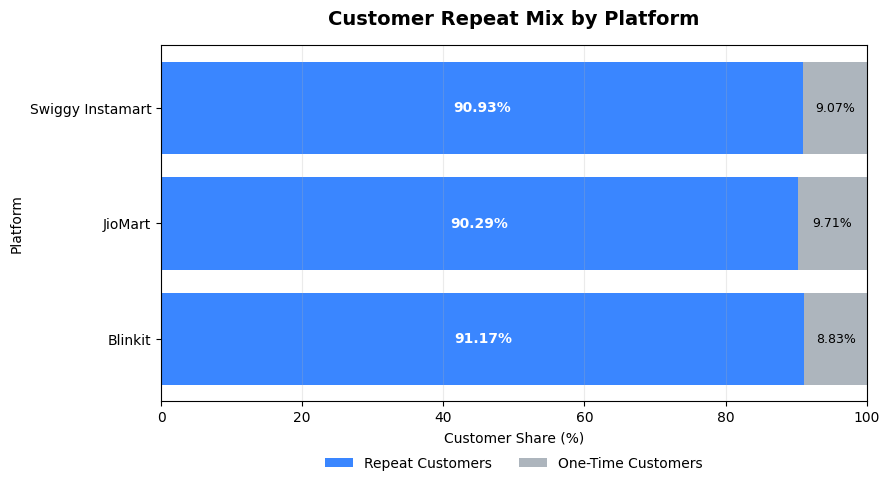

In [28]:
platform_repeat_chart = platform_repeat_summary.copy()

platform_repeat_chart["one_time_customers"] = (
    platform_repeat_chart["unique_customers"] - platform_repeat_chart["repeat_customers"]
)

platform_repeat_chart["one_time_customer_rate"] = (
    platform_repeat_chart["one_time_customers"] / platform_repeat_chart["unique_customers"] * 100
).round(2)

plt.figure(figsize=(9, 5))

plt.barh(
    platform_repeat_chart["platform"],
    platform_repeat_chart["repeat_customer_rate"],
    label="Repeat Customers",
    color="#3A86FF"
)

plt.barh(
    platform_repeat_chart["platform"],
    platform_repeat_chart["one_time_customer_rate"],
    left=platform_repeat_chart["repeat_customer_rate"],
    label="One-Time Customers",
    color="#ADB5BD"
)

plt.title(
    "Customer Repeat Mix by Platform",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Customer Share (%)")
plt.ylabel("Platform")
plt.xlim(0, 100)

for i, row in platform_repeat_chart.iterrows():
    plt.text(
        row["repeat_customer_rate"] / 2,
        i,
        f'{row["repeat_customer_rate"]:.2f}%',
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="white"
    )

    plt.text(
        row["repeat_customer_rate"] + row["one_time_customer_rate"] / 2,
        i,
        f'{row["one_time_customer_rate"]:.2f}%',
        ha="center",
        va="center",
        fontsize=9,
        color="black"
    )

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

**Observation:** Platform-level customer repeat behavior is highly consistent across Blinkit, JioMart, and Swiggy Instamart.

All three platforms show repeat customer rates above 90%, with Blinkit slightly higher at 91.17%, followed by Swiggy Instamart at 90.93% and JioMart at 90.29%. However, the difference across platforms is very small, so no platform shows a strong standalone advantage in repeat customer behavior.

Average orders per customer, order share, average delivery time, service rating, delay rate, and refund rate are also closely aligned across platforms. This suggests that platform alone does not strongly explain differences in repeat behavior, refunds, delays, or customer ratings at this stage.


## EDA Key Findings Scorecard

In [32]:
eda_key_findings = pd.DataFrame({
    "analysis_area": [
        "Platform Performance",
        "Delivery Performance",
        "Customer Ratings",
        "Refund Behavior",
        "Product Category",
        "Feedback Category",
        "Refund Relationship",
        "Order Value Segment",
        "Customer Frequency",
        "Platform Repeat Customers"
    ],
    "key_finding": [
        "Platform metrics are broadly balanced across Blinkit, JioMart, and Swiggy Instamart.",
        "Delivery groups differ in delivery time, but service ratings remain almost similar.",
        "Ratings are polarized, with high volume in 5-star ratings and low ratings.",
        "Refund request rate is high at approximately 45.82%.",
        "Product categories are balanced in order share, but average order value differs strongly.",
        "Issue-based feedback categories show the clearest refund pattern.",
        "Refunds are more clearly separated by rating and feedback than by delivery delay.",
        "Order value segments do not show a strong visible difference in refund or rating behavior.",
        "High-frequency customers contribute a larger order share than their customer share.",
        "Repeat customer rates are above 90% across all platforms and remain broadly balanced."
    ],
    "business_meaning": [
        "Platform alone does not strongly explain differences in refunds, ratings, or delivery outcomes.",
        "Delivery speed alone does not appear to explain customer satisfaction differences at this stage.",
        "Low ratings are an important customer experience risk signal.",
        "Refund behavior is a major business concern and requires deeper investigation.",
        "Product category is useful for spending analysis, but not a strong standalone refund driver.",
        "Customer feedback is a strong signal for identifying refund-related issues.",
        "Customer experience signals are more useful than delay status alone for refund analysis.",
        "Spending level does not appear to be the main driver of refunds at this stage.",
        "High-frequency customers are important for repeat-order and retention-focused analysis.",
        "Platform repeat behavior is strong but does not create a major difference across platforms."
    ],
    "project_application": [
        "Platform KPI comparison in Power BI",
        "Delivery performance monitoring",
        "Customer satisfaction tracking",
        "Refund behavior analysis",
        "Category-level revenue and basket analysis",
        "Customer issue grouping and experience analysis",
        "Decision intelligence recommendations",
        "Order value segmentation in dashboards",
        "Customer engagement and retention analysis",
        "Platform-level repeat customer KPI tracking"
    ]
})

eda_key_findings

,analysis_area,key_finding,business_meaning,project_application
0,Platform Performance,Platform metrics are broadly balanced across B...,Platform alone does not strongly explain diffe...,Platform KPI comparison in Power BI
1,Delivery Performance,"Delivery groups differ in delivery time, but s...",Delivery speed alone does not appear to explai...,Delivery performance monitoring
2,Customer Ratings,"Ratings are polarized, with high volume in 5-s...",Low ratings are an important customer experien...,Customer satisfaction tracking
3,Refund Behavior,Refund request rate is high at approximately 4...,Refund behavior is a major business concern an...,Refund behavior analysis
4,Product Category,Product categories are balanced in order share...,Product category is useful for spending analys...,Category-level revenue and basket analysis
5,Feedback Category,Issue-based feedback categories show the clear...,Customer feedback is a strong signal for ident...,Customer issue grouping and experience analysis
6,Refund Relationship,Refunds are more clearly separated by rating a...,Customer experience signals are more useful th...,Decision intelligence recommendations
7,Order Value Segment,Order value segments do not show a strong visi...,Spending level does not appear to be the main ...,Order value segmentation in dashboards
8,Customer Frequency,High-frequency customers contribute a larger o...,High-frequency customers are important for rep...,Customer engagement and retention analysis
9,Platform Repeat Customers,Repeat customer rates are above 90% across all...,Platform repeat behavior is strong but does no...,Platform-level repeat customer KPI tracking


## EDA Summary and Project Handoff

| Status | Area | Summary |
|---|---|---|
| ✅ | Platform Performance | Platform-level metrics are broadly balanced across Blinkit, JioMart, and Swiggy Instamart. |
| ✅ | Delivery Performance | Slow delivery has higher delay rate, but delivery performance does not show a strong difference in service rating. |
| ✅ | Customer Ratings | Low ratings are strongly linked with refund requests. |
| ✅ | Refund Behavior | Refund request rate is high and should be treated as a major business concern. |
| ✅ | Product Category | Product categories differ mainly in average order value, not strongly in refund or rating behavior. |
| ✅ | Feedback Category | Issue-based feedback categories show the clearest refund pattern. |
| ✅ | Refund Relationship | Refunds are more clearly linked with rating and feedback than with delivery delay. |
| ✅ | Order Value Segment | Order value does not show a strong visible difference in refund behavior. |
| ✅ | Customer Frequency | High-frequency customers contribute a larger order share than their customer share. |
| ✅ | Platform Repeat Customers | Repeat customer behavior is strong and balanced across platforms. |


**Final EDA Conclusion:**
The key business concern identified in this exploratory analysis is the high refund request rate. Service rating and feedback category appear to be the strongest refund-related signals, while platform, product category, order value segment, customer frequency, and delivery delay provide useful business context.

These findings will support SQL business queries, Power BI dashboarding, KPI monitoring, customer experience analysis, and decision intelligence recommendations.
